# Complex-enrichment figures

Fig. 2e and Supplementary Fig. S5c from the CORUM complex-enrichment tables. Each panel is written to `figures/` (PDF) and the values it plots to `data/` (CSV).

The notebook reads the frozen paper results (`results_reference/`) by default. To plot a rerun, run `bash <stage>/run.sh` for stages 1, 2, 5 and 7 (`compute_magnitude_enrichment.py` reads `PAPER_EFFECT_DICT`), then set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to read `results/`.

In [1]:
%matplotlib inline
import io
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import COMPLEX_ENRICHMENT, DATASET_ORDER, REPO_ROOT, paper_name, reference

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"

ENRICHMENT = reference(COMPLEX_ENRICHMENT) if USE_REFERENCE else COMPLEX_ENRICHMENT
FIG2E_INPUT = ENRICHMENT / "complex_specific_magnitude_enrichment/complex_specific_magnitude_enrichment_curves.csv"
S5C_INPUT = ENRICHMENT / "complex_level_top5_enrichment/complex_top5_enrichment_long.csv"

FIGURES = REPO_ROOT / "7_complex_enrichment" / "figures"
DATA = REPO_ROOT / "7_complex_enrichment" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

DISPLAY_DPI = 110  # inline previews only; the PDFs are vector
MM = 1.0 / 25.4

# The 11 screens of both panels, top to bottom in S5c, by paper name.
# Feng-GW-iPSC, also in the Fig 2e table, is not drawn.
DATASETS = [paper_name(dataset) for dataset in DATASET_ORDER if dataset != "Feng-GW"]


def show_inline(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=DISPLAY_DPI, facecolor="white")
    display(Image(data=buffer.getvalue()))

## Fig. 2e — complex-specific enrichment by |residual effect|

The 11 screens (gray) and their pointwise median (blue): `COMPLEX_ENRICHMENT` (`complex_specific_magnitude_enrichment/complex_specific_magnitude_enrichment_curves.csv`), from `7_complex_enrichment/compute_magnitude_enrichment.py`.

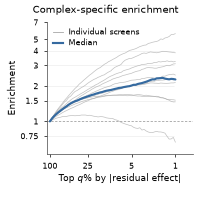

In [2]:
FIG2E_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "font.size": 5.7,
    "axes.titlesize": 6.8,
    "axes.labelsize": 6.0,
    "xtick.labelsize": 5.3,
    "ytick.labelsize": 5.3,
    "axes.linewidth": 0.50,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 0.45,
    "ytick.major.width": 0.45,
    "xtick.major.size": 2.0,
    "ytick.major.size": 2.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}

curves = pd.read_csv(FIG2E_INPUT)
curves["display_dataset"] = curves["dataset"].map(paper_name)
by_dataset = {
    dataset: curves[curves["display_dataset"].eq(dataset)].sort_values("q_percent", ascending=False)
    for dataset in DATASETS
}
q = by_dataset[DATASETS[0]]["q_percent"].to_numpy()
matrix = np.vstack([part["enrichment"].to_numpy() for part in by_dataset.values()])
median = np.median(matrix, axis=0)

screens = [
    pd.DataFrame(
        {
            "curve": "Individual screens",
            "display_dataset": part["display_dataset"].to_numpy(),
            "q_percent": part["q_percent"].to_numpy(),
            "enrichment": part["enrichment"].to_numpy(),
        }
    )
    for part in by_dataset.values()
]
median_curve = pd.DataFrame(
    {"curve": "Median", "display_dataset": f"Median of {len(DATASETS)} screens", "q_percent": q, "enrichment": median}
)
pd.concat(screens + [median_curve], ignore_index=True).to_csv(
    DATA / "complex_specific_enrichment_curves.csv", index=False
)

minimum = min(1.0, float(np.nanmin(matrix)))
maximum = max(1.0, float(np.nanmax(matrix)))
log_padding = 0.11 * max(0.4, np.log10(maximum / minimum))
lower = 10 ** (np.log10(minimum) - log_padding)
upper = 10 ** (np.log10(maximum) + log_padding)

with mpl.rc_context():
    mpl.rc_file_defaults()  # start from the matplotlibrc defaults, as the panel script did
    mpl.rcParams.update(FIG2E_RC)
    fig, ax = plt.subplots(figsize=(46 * MM, 46 * MM))
    ax.axhline(1.0, color="#9A9A9A", linewidth=0.50, linestyle=(0, (3, 2)), zorder=1)
    for part in by_dataset.values():
        ax.plot(
            part["q_percent"],
            part["enrichment"],
            color="#A7A7A7",
            linewidth=0.45,
            alpha=0.72,
            linestyle="-",
            solid_capstyle="round",
            zorder=2,
        )
    ax.plot(q, median, color="#356AA0", linewidth=1.40, zorder=5, solid_capstyle="round")

    ax.set_xscale("log")
    ax.set_xlim(112, 0.52)
    ax.set_xticks([100, 25, 5, 1])
    ax.set_xticklabels(["100", "25", "5", "1"])
    ax.tick_params(axis="x", which="minor", bottom=False)
    ax.set_yscale("log")
    ax.set_ylim(lower, upper)
    y_candidates = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0]
    y_ticks = [value for value in y_candidates if lower <= value <= upper]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{value:g}" for value in y_ticks])
    ax.tick_params(axis="y", which="minor", left=False)
    ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    # Guide lines stop short of the right edge; none at 1 (dashed) or under the legend (>= 5).
    for value in y_ticks:
        if not np.isclose(value, 1.0) and value < 5.0:
            ax.hlines(value, 112, 1.04, color="#E8E8E8", linewidth=0.35, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Top $q$% by |residual effect|", labelpad=2.2)
    ax.set_ylabel("Enrichment", labelpad=2.2)
    fig.suptitle("Complex-specific enrichment", x=0.53, y=0.975, ha="center", fontsize=6.5)
    legend_handles = [
        Line2D([0], [0], color="#A7A7A7", linewidth=0.55, label="Individual screens"),
        Line2D([0], [0], color="#356AA0", linewidth=1.40, label="Median"),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        frameon=False,
        fontsize=5.0,
        handlelength=1.35,
        handletextpad=0.75,
        labelspacing=0.25,
        borderaxespad=0.35,
    )
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#555555")
    fig.subplots_adjust(left=0.235, right=0.97, bottom=0.225, top=0.89)

    show_inline(fig)
    fig.savefig(FIGURES / "complex_specific_enrichment_curves.pdf", facecolor="white")
    plt.close(fig)

## Supplementary Fig. S5c — complex-level top-5% enrichment

11 datasets × 27 CORUM complexes: `COMPLEX_ENRICHMENT` (`complex_level_top5_enrichment/complex_top5_enrichment_long.csv`), from `7_complex_enrichment/compute_magnitude_enrichment.py`. A circle marks a complex with n_A ≥ 3 measured targets (area ∝ sqrt(n_A)); it is gray when no complex-specific gene was selected.

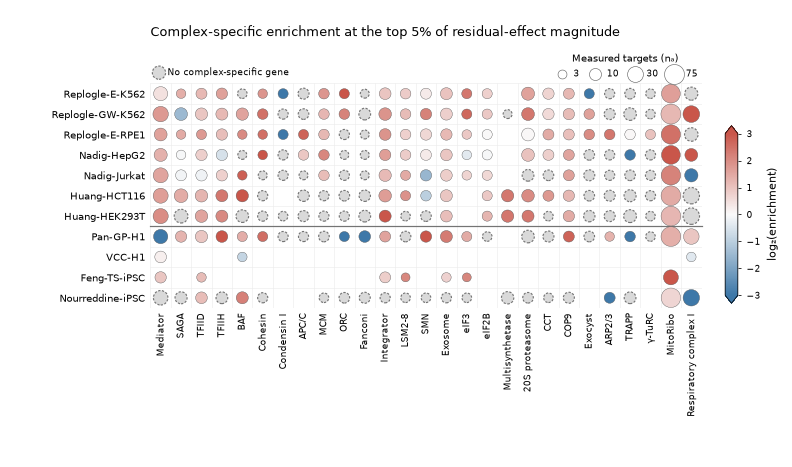

In [3]:
S5C_COMPLEXES = [
    "Mediator", "SAGA", "TFIID", "TFIIH", "BAF", "Cohesin", "Condensin_I",
    "APC/C", "MCM", "ORC", "Fanconi", "Integrator", "LSM2-8", "SMN",
    "Exosome", "eIF3", "EIF2B", "Multisynthetase", "20S_prot", "CCT",
    "COP9", "Exocyst", "ARP2/3", "TRAPP", "gamma-TuRC", "MitoRibo",
    "RespCplxI",
]
COMPLEX_LABELS = {
    "Condensin_I": "Condensin I",
    "EIF2B": "eIF2B",
    "20S_prot": "20S proteasome",
    "gamma-TuRC": "γ-TuRC",
    "RespCplxI": "Respiratory complex I",
}
S5C_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "font.size": 7.0,
    "axes.titlesize": 8.5,
    "axes.labelsize": 7.5,
    "xtick.labelsize": 6.0,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}

table = pd.read_csv(S5C_INPUT)
names = table["dataset"].map(paper_name)
eligible = table["n_measured_perturbations"].ge(3)  # n_A < 3: blank cell
has_gene = table["status"].isin({"available", "available_zero_top5_share"})
colored_cells = eligible & has_gene
gray_cells = eligible & ~has_gene

# Fixed symmetric limits; zero enrichment (log2 = -inf) is shown at -3, not as missing.
color_limit = 3.0
color_value = table["log2_top5_enrichment"].copy()
color_value = color_value.mask(np.isneginf(color_value), -color_limit)
color_value = color_value.clip(lower=-color_limit, upper=color_limit)

x = table["complex"].map({name: i for i, name in enumerate(S5C_COMPLEXES)}).to_numpy(float)
y = names.map({name: i for i, name in enumerate(DATASETS)}).to_numpy(float)
n_targets = table["n_measured_perturbations"].to_numpy(float)


def bubble_area(counts):
    """Marker area in pt^2, proportional to sqrt(n_A); 170 at the largest n_A."""
    return 170.0 * np.power(np.asarray(counts, dtype=float) / float(n_targets.max()), 0.5)


marker_area = bubble_area(n_targets)

# One row per circle, datasets top to bottom, complexes left to right.
values = pd.DataFrame(
    {
        "display_dataset": names,
        "complex": table["complex"].map(lambda name: COMPLEX_LABELS.get(name, name)),
        "circle": np.where(has_gene, "colored", "gray (no complex-specific gene)"),
        "n_measured_perturbations": table["n_measured_perturbations"],
        "bubble_area_pt2": marker_area,
        "top5_enrichment": table["top5_enrichment"],
        "log2_top5_enrichment": table["log2_top5_enrichment"],
        "log2_enrichment_color": color_value.where(has_gene),
    }
)
order = pd.DataFrame({"row": y, "column": x})[eligible].sort_values(["row", "column"]).index
values.loc[order].reset_index(drop=True).to_csv(
    DATA / "complex_specific_enrichment_top5_by_complex.csv", index=False
)

cmap = LinearSegmentedColormap.from_list("muted_blue_white_red", ["#3E78A8", "#FAFAFA", "#C9564A"], N=256)
norm = TwoSlopeNorm(vmin=-color_limit, vcenter=0.0, vmax=color_limit)

with mpl.rc_context(S5C_RC):
    fig, ax = plt.subplots(figsize=(183 * MM, 108 * MM))
    colored = ax.scatter(
        x[colored_cells],
        y[colored_cells],
        s=marker_area[colored_cells],
        c=color_value[colored_cells],
        cmap=cmap,
        norm=norm,
        marker="o",
        edgecolors="#555555",
        linewidths=0.25,
        zorder=3,
    )
    no_gene_bubbles = ax.scatter(
        x[gray_cells],
        y[gray_cells],
        s=marker_area[gray_cells],
        facecolors="#D9D9D9",
        marker="o",
        edgecolors="#747474",
        linewidths=0.75,
        linestyles=(0, (2.0, 1.35)),
        zorder=2,
    )

    ax.set_xticks(np.arange(len(S5C_COMPLEXES)))
    ax.set_xticklabels(
        [COMPLEX_LABELS.get(name, name) for name in S5C_COMPLEXES],
        rotation=90,
        rotation_mode="anchor",
        ha="right",
        va="center",
    )
    ax.set_yticks(np.arange(len(DATASETS)))
    ax.set_yticklabels(DATASETS)
    ax.set_xlim(-0.5, len(S5C_COMPLEXES) - 0.5)
    ax.set_ylim(len(DATASETS) - 0.5, -0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(axis="both", which="major", length=0)
    ax.set_xticks(np.arange(-0.5, len(S5C_COMPLEXES), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(DATASETS), 1), minor=True)
    ax.grid(which="minor", color="#ECECEC", linewidth=0.38)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.axhline(6.5, color="#747474", linewidth=0.8, clip_on=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(
        "Complex-specific enrichment at the top 5% of residual-effect magnitude",
        loc="left",
        pad=31,
    )

    colorbar_ax = fig.add_axes([0.915, 0.35, 0.016, 0.38])
    colorbar = fig.colorbar(colored, cax=colorbar_ax, ticks=np.arange(-3, 4, 1), extend="both")
    colorbar.ax.tick_params(labelsize=6.0, width=0.5, length=2.2)
    colorbar.outline.set_linewidth(0.5)
    colorbar.set_label("log₂(enrichment)", fontsize=7.0, labelpad=4)
    no_gene_legend = ax.legend(
        handles=[no_gene_bubbles],
        labels=["No complex-specific gene"],
        loc="lower left",
        bbox_to_anchor=(0.0, 1.01),
        frameon=False,
        fontsize=6.2,
        handlelength=1.0,
        handletextpad=0.4,
        borderaxespad=0,
    )
    ax.add_artist(no_gene_legend)
    size_handles = [
        ax.scatter(
            [], [], s=float(bubble_area(count)), facecolors="white",
            edgecolors="#666666", linewidths=0.4, label=str(count)
        )
        for count in [3, 10, 30, 75]
    ]
    ax.legend(
        handles=size_handles,
        title="Measured targets (nₐ)",
        loc="lower right",
        bbox_to_anchor=(1.0, 1.005),
        ncol=4,
        frameon=False,
        fontsize=6.0,
        title_fontsize=6.3,
        handletextpad=0.25,
        columnspacing=0.75,
        borderaxespad=0,
    )
    fig.subplots_adjust(left=0.18, right=0.895, bottom=0.34, top=0.82)

    fig.savefig(FIGURES / "complex_specific_enrichment_top5_by_complex.pdf", facecolor="white")
    show_inline(fig)
    plt.close(fig)